## Imports and definitions

In [27]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from lmfit import Model, Parameter
import matplotlib as mlp
from matplotlib.ticker import AutoMinorLocator, FuncFormatter, NullFormatter

#Temperatures for T1 measurements on the main peak (X0)

dictX0={'2.04' : 0,'2.28' : 1,'2.69' : 2,'2.94' : 3,'3.15' : 4,'3.5' : 5, '3.75' : 6,'4' : 7,'5' : 8,'6' : 9,'8' : 10,'10' : 11,'12' : 12, '15' : 13,
        '18' : 14,'21' : 15,'24' : 16,'27' : 17,'30' : 18, '35' : 19, '40' : 20,'45' : 21,'50' : 22,'55' : 23,'60' : 24,'70' : 25,'75' : 26,'80' : 27,
        '85' : 28,'90' : 29,'95':30,'100' : 31,'110' : 32,'115':33,'120' : 34,'130':35,'140' : 36,'150':37,'160' : 38,'170':39,'180' : 40,'200' : 41}
X0=[2.04,2.28,2.69,2.94,3.15,3.5,3.75,4,5,6,8,10,12,15,18,21,24,27,30,35,40,45,50,55,60,70,75,80,85,90,95,100,110,115,120,130,140,150,160,170,180,200]

#Defect T1 times, obtained with fixed stretch = 0.72, interpolated to X0 temperatures!

T1d_values_file=r'NMR200_19F_T1vsT_defect_0p72_interpolated.dat'
T1d_values=pd.read_csv(T1d_values_file, sep='\t', header=0, skiprows=[1,2])
#print(T1d_values)

#Originally measured defect T1 times with fixed stretch = 0.72. To plot and compare!

columns01=['T', 'FR', 'y0', 'err y0', 'T1', 'err T1', 'r', 'err r', 's', 'err s']
T1d_original_file=r'NMR200_19F_T1vsT_defect_0p72.txt'
T1d_original=pd.read_csv(T1d_original_file, sep='\t', header=None, names=columns01)
#print(T1d_original)

#Parameters of the new NMR spectral analysis. 'int' is just int1+int2

fileXKparametri = r'NMRspecAnalysis.dat'
columns2=['T','int','freq1','freq1_err','sigma1','sigma1_err','freq2','freq2_err','sigma2','sigma2_err','k','k_err','Int1','Int1_err','Int2','Int2_err']
parametrizafitX = pd.read_csv(fileXKparametri, sep='	', names=columns2, header=0, index_col=False)

#INTERPOLACIJA
paramsExceptT = parametrizafitX.columns[1:]          # everything except T
interp = interp1d(parametrizafitX['T'], parametrizafitX[paramsExceptT].to_numpy(), axis=0, kind='linear', bounds_error=False, fill_value='extrapolate')# bounds_error=True)
def get_params(T):
    return pd.Series(interp(T), index=paramsExceptT)

#An older T1vsT analysis with only one component. Only to extract the frequencies where those measurements were made!
magFile=r'NMR200_19F_T1vsT_narrow_new.txt'
dataMag=pd.read_csv(magFile, sep="	", names=columns01)
#print(dataMag)

#Functions
def gaussian(x,a,nu,b):
    return(a/(np.sqrt(2*np.pi)*b))*np.exp(-(x-nu)**2/(2*b**2))
 
def fitmagnetizacija(t,s,T1M,r,y0):
    x=nu3
    y=y0*((k)*gaussian(x,a,nu,b)*(1-(1+s)*np.exp(-(t/T1M)**r))+(1-k)*gaussian(x,a,nu1,b1)*(1-(1+s)*np.exp(-(t/T1D)**0.72)))
    return y
    
def main(t,s,T,r,y0):
    x=nu3
    y=y0*(k)*gaussian(x,a,nu,b)*(1-(1+s)*np.exp(-(t/T)**r))
    return y  
    
def defect(t,s,y0):
    x=nu3
    y=y0*(1-k)*gaussian(x,a,nu1,b1)*(1-(1+s)*np.exp(-(t/T1D)**0.72))
    return y     

def intrinsic_fraction(k, x, nu, b, nu1, b1):
    return (k)*gaussian(x,1,nu,b) / ((k)*gaussian(x,1,nu,b) + (1-k)*gaussian(x,1,nu1,b1))

## Fitting

Temperature: 2.04 K, interpolated spectral parameters:
    -Intrinsic component: 188.218 MHz, sigma = 0.255 MHz
    -Defect component: 187.907 MHz, sigma = 0.776 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.530
Fraction of intrinsic component at 188.2 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.786


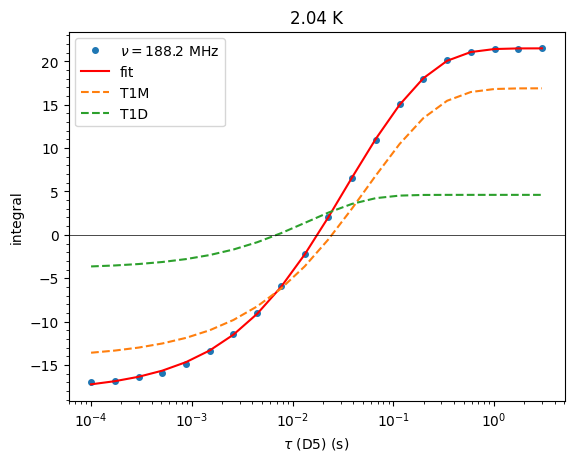

s = 0.842403555875795 +/- 0.004271090523720789
T1M = 0.055035255809447854 +/- 0.0006701881274359597
r = 0.614573204083847 +/- 0.006178030210023394
y0 = 20.484351761634407 +/- 0.06419905941314817

----------------------------------------------------------------------------------------------------

Temperature: 2.28 K, interpolated spectral parameters:
    -Intrinsic component: 188.217 MHz, sigma = 0.246 MHz
    -Defect component: 187.910 MHz, sigma = 0.748 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.540
Fraction of intrinsic component at 188.2 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.793


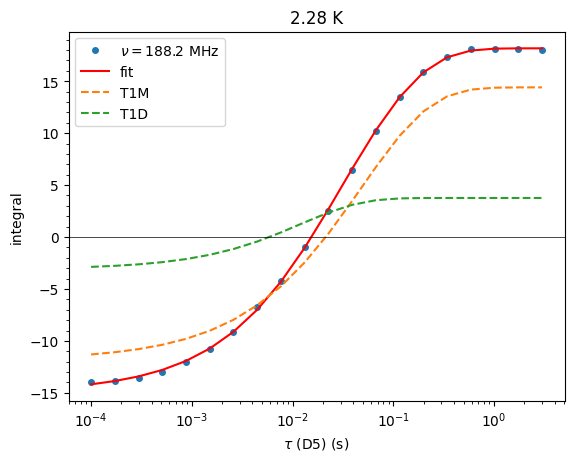

s = 0.8221358847668474 +/- 0.004756303359615218
T1M = 0.04835041263851021 +/- 0.000639256463798488
r = 0.6269889293965388 +/- 0.007062257296177682
y0 = 16.507991624163505 +/- 0.05541101724370824

----------------------------------------------------------------------------------------------------

Temperature: 2.69 K, interpolated spectral parameters:
    -Intrinsic component: 188.217 MHz, sigma = 0.234 MHz
    -Defect component: 187.917 MHz, sigma = 0.714 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.554
Fraction of intrinsic component at 188.2 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.803


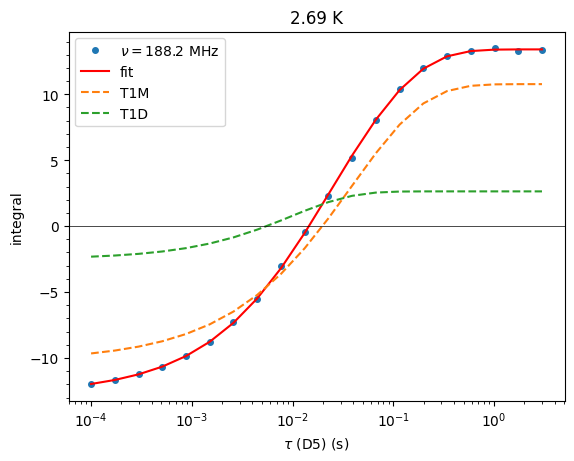

s = 0.9504580754103797 +/- 0.005698053660709496
T1M = 0.038898193452399824 +/- 0.0005304469114522046
r = 0.5998838051491289 +/- 0.006971622992492162
y0 = 11.425940825036184 +/- 0.04049777991884516

----------------------------------------------------------------------------------------------------

Temperature: 2.94 K, interpolated spectral parameters:
    -Intrinsic component: 188.216 MHz, sigma = 0.229 MHz
    -Defect component: 187.921 MHz, sigma = 0.702 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.559
Fraction of intrinsic component at 188.2 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.808


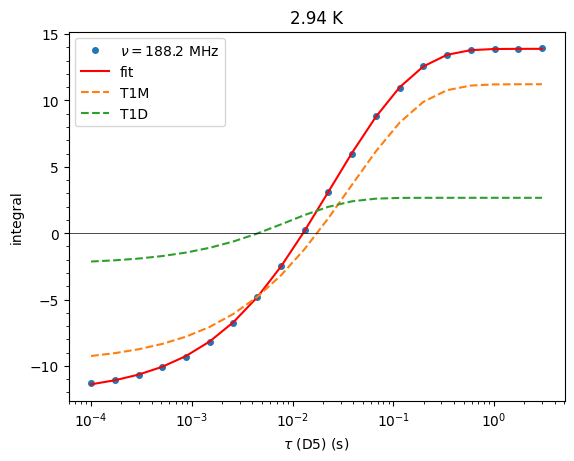

s = 0.8737960305263897 +/- 0.003432119805666327
T1M = 0.03765641602185277 +/- 0.0003225643987807908
r = 0.6106407071669223 +/- 0.004516200447556087
y0 = 11.526392205308843 +/- 0.02486640152372952

----------------------------------------------------------------------------------------------------

Temperature: 3.15 K, interpolated spectral parameters:
    -Intrinsic component: 188.216 MHz, sigma = 0.223 MHz
    -Defect component: 187.926 MHz, sigma = 0.678 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.560
Fraction of intrinsic component at 188.2 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.807


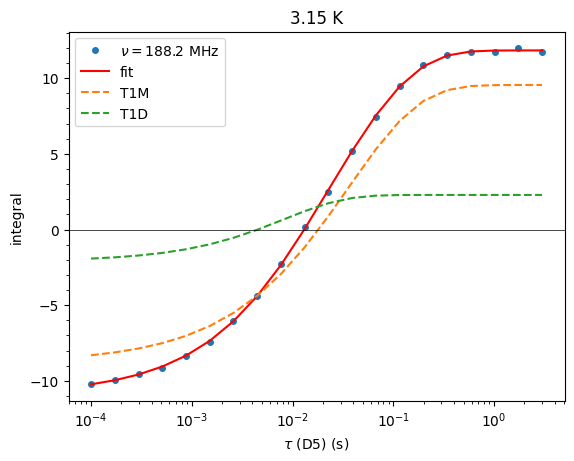

s = 0.9201687318855312 +/- 0.005732825541823151
T1M = 0.03629459340420453 +/- 0.0004975070946927273
r = 0.6159233158266871 +/- 0.00735539078825907
y0 = 9.571107095015618 +/- 0.03374851751342913

----------------------------------------------------------------------------------------------------

Temperature: 3.5 K, interpolated spectral parameters:
    -Intrinsic component: 188.218 MHz, sigma = 0.214 MHz
    -Defect component: 187.934 MHz, sigma = 0.627 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.558
Fraction of intrinsic component at 188.2 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.802


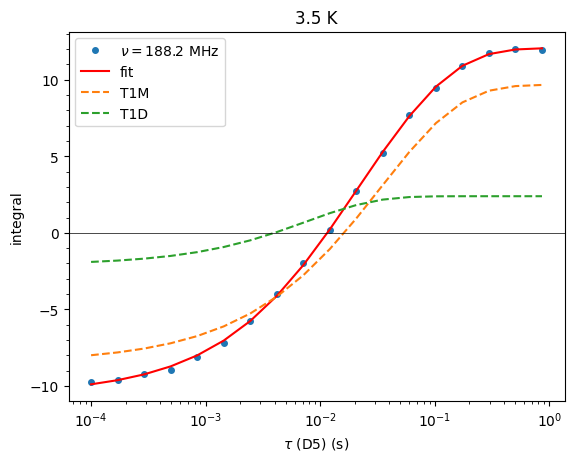

s = 0.8757578459513864 +/- 0.007669745078418874
T1M = 0.03410617568208169 +/- 0.0006992729544824786
r = 0.6226113827330113 +/- 0.01039539043072808
y0 = 9.31105115673385 +/- 0.05844141843049572

----------------------------------------------------------------------------------------------------

Temperature: 3.75 K, interpolated spectral parameters:
    -Intrinsic component: 188.218 MHz, sigma = 0.207 MHz
    -Defect component: 187.940 MHz, sigma = 0.591 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.557
Fraction of intrinsic component at 188.2 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.798


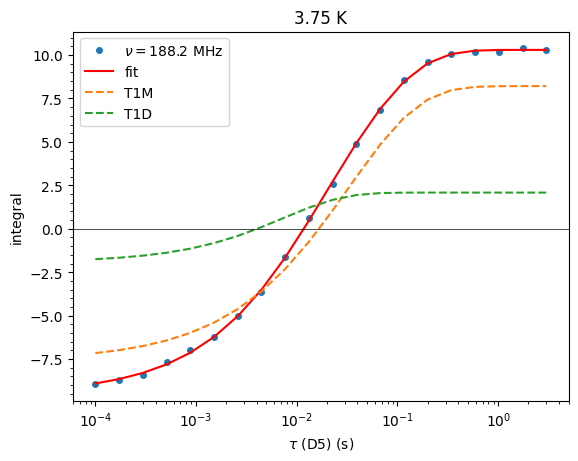

s = 0.9244978675449571 +/- 0.007635605842253876
T1M = 0.03313345326439943 +/- 0.0005991145052242851
r = 0.6154520377124866 +/- 0.009770396089036817
y0 = 7.678009093968953 +/- 0.034810282951874584

----------------------------------------------------------------------------------------------------

Temperature: 4 K, interpolated spectral parameters:
    -Intrinsic component: 188.219 MHz, sigma = 0.200 MHz
    -Defect component: 187.946 MHz, sigma = 0.554 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.556
Fraction of intrinsic component at 188.202 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.794


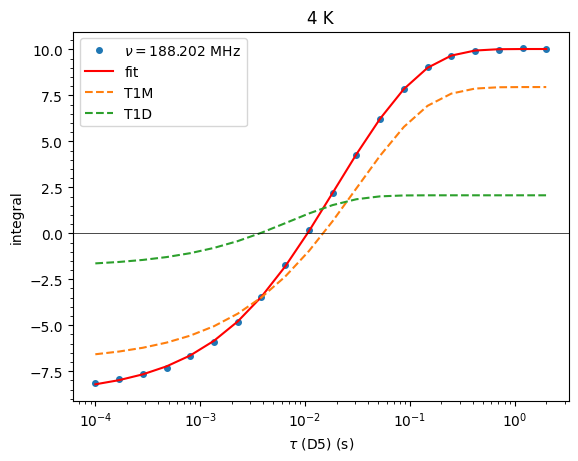

s = 0.8754225351153079 +/- 0.0037859529419018213
T1M = 0.03109830137528109 +/- 0.00028999631504937113
r = 0.6337185519200936 +/- 0.005244209114540307
y0 = 7.206016027164417 +/- 0.017403098265816184

----------------------------------------------------------------------------------------------------

Temperature: 5 K, interpolated spectral parameters:
    -Intrinsic component: 188.224 MHz, sigma = 0.187 MHz
    -Defect component: 187.972 MHz, sigma = 0.505 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.542
Fraction of intrinsic component at 188.203 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.779


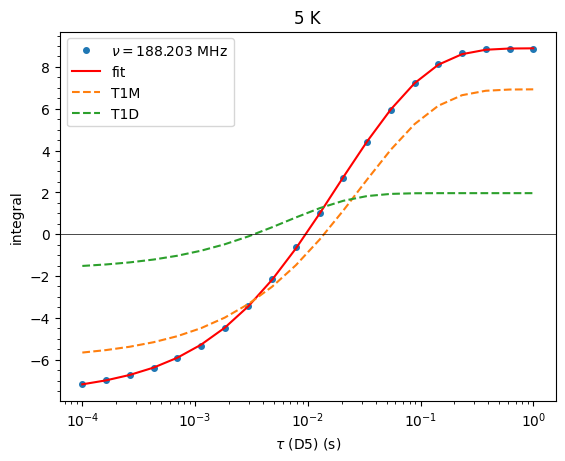

s = 0.8646823014561704 +/- 0.002928874987587544
T1M = 0.029124622691028914 +/- 0.0002212750496463043
r = 0.6450130756566067 +/- 0.004243511422981252
y0 = 6.019159848778266 +/- 0.012909629071954696

----------------------------------------------------------------------------------------------------

Temperature: 6 K, interpolated spectral parameters:
    -Intrinsic component: 188.227 MHz, sigma = 0.165 MHz
    -Defect component: 187.993 MHz, sigma = 0.444 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.527
Fraction of intrinsic component at 188.216 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.772


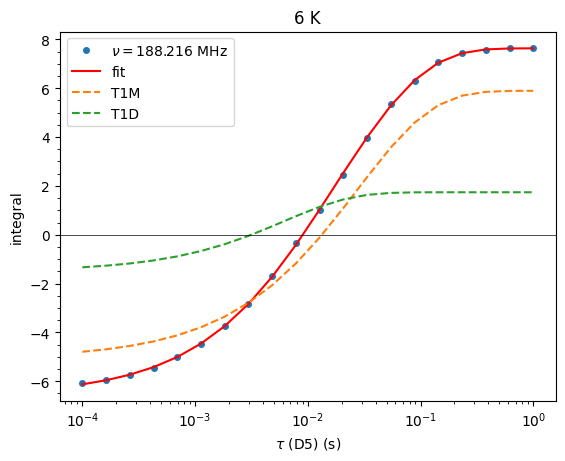

s = 0.8600047284654704 +/- 0.00378791509158677
T1M = 0.027759599933566293 +/- 0.00027232275587379023
r = 0.6518365198781935 +/- 0.005610209414894678
y0 = 4.642712336402961 +/- 0.01263415792962985

----------------------------------------------------------------------------------------------------

Temperature: 8 K, interpolated spectral parameters:
    -Intrinsic component: 188.229 MHz, sigma = 0.142 MHz
    -Defect component: 188.025 MHz, sigma = 0.365 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.499
Fraction of intrinsic component at 188.221 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.747


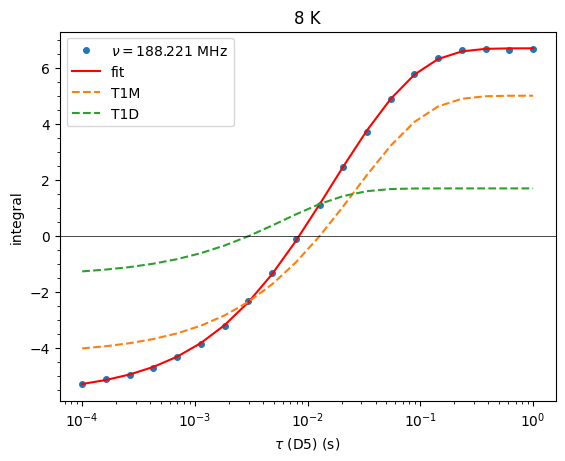

s = 0.8446749068908912 +/- 0.004486859854223325
T1M = 0.02631849006036063 +/- 0.0003123482974140775
r = 0.6824181035881989 +/- 0.007363748223198627
y0 = 3.5789959237609246 +/- 0.011400282358757155

----------------------------------------------------------------------------------------------------

Temperature: 10 K, interpolated spectral parameters:
    -Intrinsic component: 188.233 MHz, sigma = 0.118 MHz
    -Defect component: 188.053 MHz, sigma = 0.294 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.480
Fraction of intrinsic component at 188.222 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.730


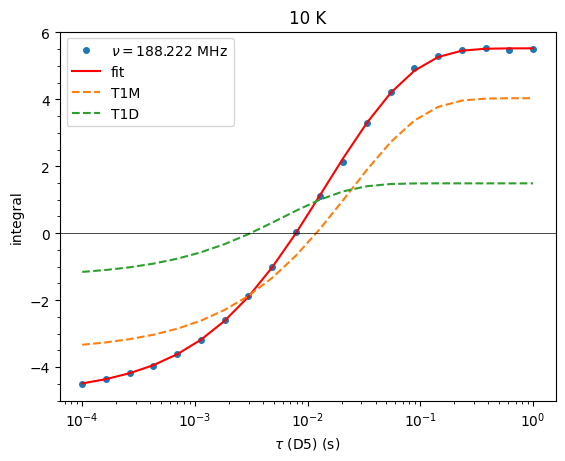

s = 0.8718575576789459 +/- 0.005778899689622968
T1M = 0.02380189754629982 +/- 0.0003563865378707075
r = 0.6757870561034491 +/- 0.00930210743315044
y0 = 2.489093538336349 +/- 0.009699616392386283

----------------------------------------------------------------------------------------------------

Temperature: 12 K, interpolated spectral parameters:
    -Intrinsic component: 188.236 MHz, sigma = 0.106 MHz
    -Defect component: 188.075 MHz, sigma = 0.262 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.455
Fraction of intrinsic component at 188.226 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.709


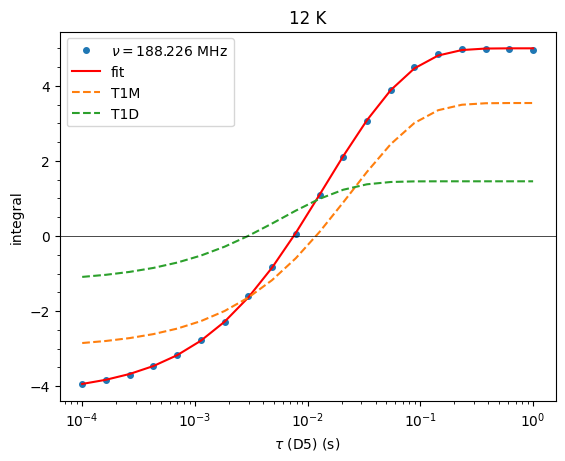

s = 0.843772060921517 +/- 0.003937806949909161
T1M = 0.023908971471630697 +/- 0.0002554840905439034
r = 0.7027518222048574 +/- 0.007041603003035973
y0 = 2.07462341550502 +/- 0.005609995917385836

----------------------------------------------------------------------------------------------------

Temperature: 15 K, interpolated spectral parameters:
    -Intrinsic component: 188.241 MHz, sigma = 0.088 MHz
    -Defect component: 188.100 MHz, sigma = 0.213 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.433
Fraction of intrinsic component at 188.232 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.690


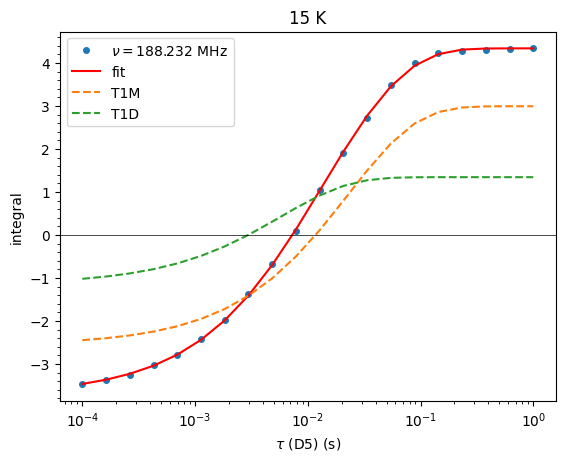

s = 0.8535185029463784 +/- 0.0057840467590373115
T1M = 0.02299431847108797 +/- 0.0003630618336127413
r = 0.7162185884167112 +/- 0.010781265393617222
y0 = 1.534789440380949 +/- 0.006012637887335286

----------------------------------------------------------------------------------------------------

Temperature: 18 K, interpolated spectral parameters:
    -Intrinsic component: 188.243 MHz, sigma = 0.077 MHz
    -Defect component: 188.117 MHz, sigma = 0.186 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.415
Fraction of intrinsic component at 188.235 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.676


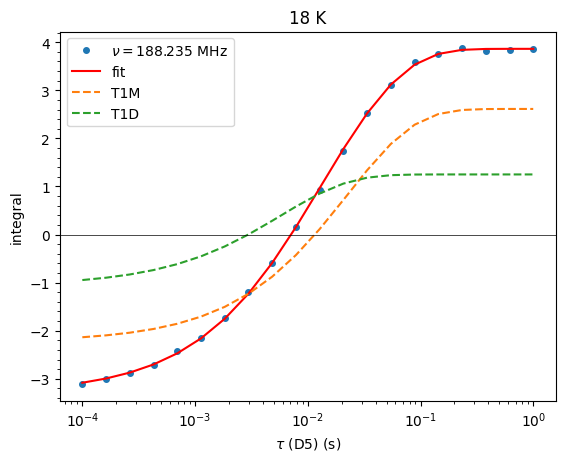

s = 0.8539462226247219 +/- 0.005477328858201886
T1M = 0.0225448730436555 +/- 0.00034161151212078867
r = 0.7238172563950395 +/- 0.010548966265132154
y0 = 1.2186157257736645 +/- 0.004497439966946106

----------------------------------------------------------------------------------------------------

Temperature: 21 K, interpolated spectral parameters:
    -Intrinsic component: 188.245 MHz, sigma = 0.068 MHz
    -Defect component: 188.130 MHz, sigma = 0.165 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.397
Fraction of intrinsic component at 188.237 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.660


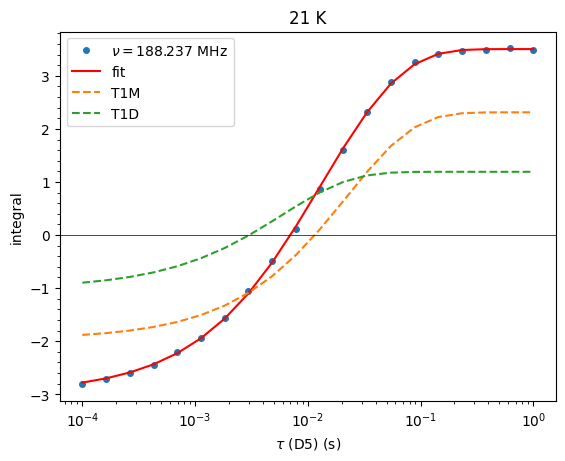

s = 0.8490670495310746 +/- 0.0060738885613723734
T1M = 0.02252049746802055 +/- 0.00038888071106764626
r = 0.7295882955323381 +/- 0.012167477006014627
y0 = 1.0067805174242261 +/- 0.00413346079402513

----------------------------------------------------------------------------------------------------

Temperature: 24 K, interpolated spectral parameters:
    -Intrinsic component: 188.247 MHz, sigma = 0.063 MHz
    -Defect component: 188.140 MHz, sigma = 0.151 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.375
Fraction of intrinsic component at 188.238 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.637


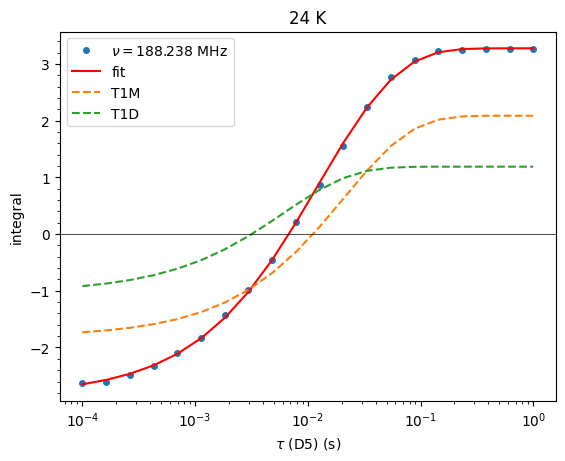

s = 0.8667662314949135 +/- 0.006220230023976079
T1M = 0.021297349595535923 +/- 0.0003797303736130335
r = 0.7290185601493709 +/- 0.012676626990951644
y0 = 0.8882156040030298 +/- 0.0036362870775530102

----------------------------------------------------------------------------------------------------

Temperature: 27 K, interpolated spectral parameters:
    -Intrinsic component: 188.248 MHz, sigma = 0.058 MHz
    -Defect component: 188.148 MHz, sigma = 0.137 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.367
Fraction of intrinsic component at 188.239 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.628


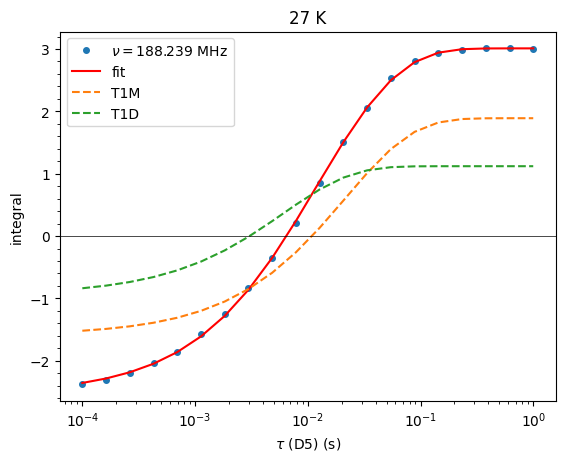

s = 0.8412252351207368 +/- 0.0053290357642728735
T1M = 0.0216248249200764 +/- 0.00034457824928367357
r = 0.7216454283450952 +/- 0.011071961169351512
y0 = 0.7583753040609608 +/- 0.0026867071596116043

----------------------------------------------------------------------------------------------------

Temperature: 30 K, interpolated spectral parameters:
    -Intrinsic component: 188.246 MHz, sigma = 0.055 MHz
    -Defect component: 188.152 MHz, sigma = 0.122 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.366
Fraction of intrinsic component at 188.238 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.621


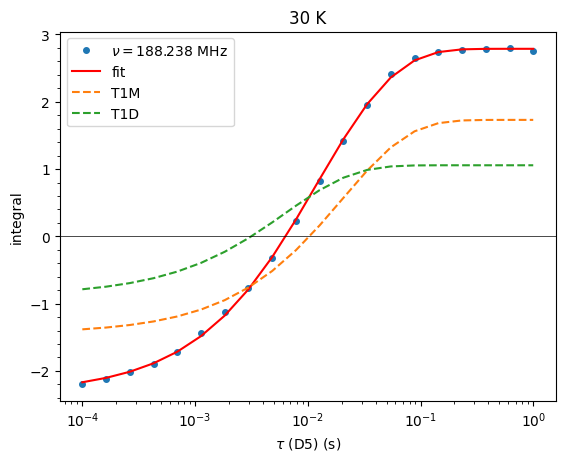

s = 0.8349781661933553 +/- 0.007933599386368449
T1M = 0.020477827577187118 +/- 0.00048469102150439265
r = 0.733900413824441 +/- 0.017153409965625088
y0 = 0.6544514044943034 +/- 0.0033980202226587407

----------------------------------------------------------------------------------------------------

Temperature: 35 K, interpolated spectral parameters:
    -Intrinsic component: 188.248 MHz, sigma = 0.048 MHz
    -Defect component: 188.160 MHz, sigma = 0.104 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.358
Fraction of intrinsic component at 188.237 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.607


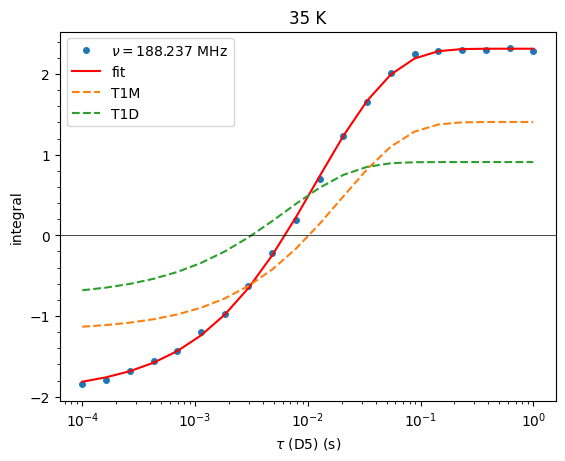

s = 0.8408850851343643 +/- 0.00878554549094658
T1M = 0.01983487718431966 +/- 0.0005228054055132145
r = 0.7508476114829675 +/- 0.01992851557115268
y0 = 0.4852689457639974 +/- 0.0027704223562218812

----------------------------------------------------------------------------------------------------

Temperature: 40 K, interpolated spectral parameters:
    -Intrinsic component: 188.248 MHz, sigma = 0.044 MHz
    -Defect component: 188.167 MHz, sigma = 0.093 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.349
Fraction of intrinsic component at 188.236 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.588


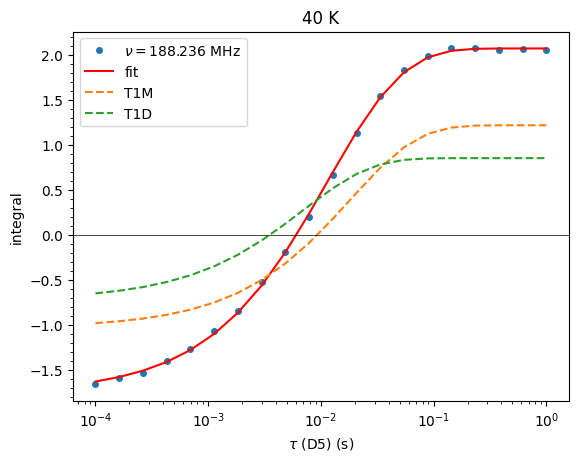

s = 0.8456710027707313 +/- 0.008761339587913523
T1M = 0.018224899563139572 +/- 0.00048432772826850014
r = 0.7262759340270919 +/- 0.01947255521712919
y0 = 0.403501382679351 +/- 0.0021916935665992642

----------------------------------------------------------------------------------------------------

Temperature: 45 K, interpolated spectral parameters:
    -Intrinsic component: 188.248 MHz, sigma = 0.042 MHz
    -Defect component: 188.171 MHz, sigma = 0.084 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.348
Fraction of intrinsic component at 188.236 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.583


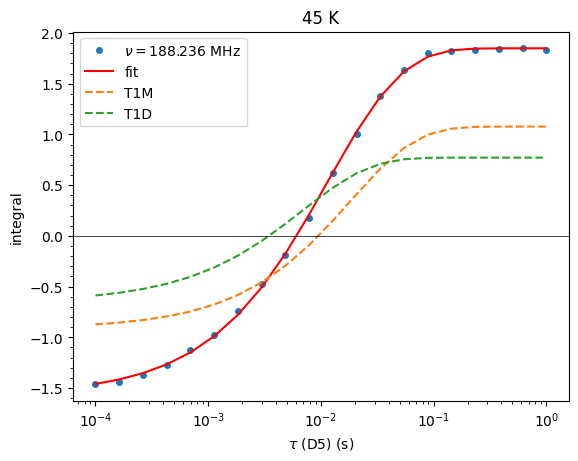

s = 0.8478770502347126 +/- 0.008703150226601954
T1M = 0.01835233579007872 +/- 0.0004877020043017456
r = 0.7416809656317652 +/- 0.020073774500488556
y0 = 0.3366239234911218 +/- 0.0018345602284640821

----------------------------------------------------------------------------------------------------

Temperature: 50 K, interpolated spectral parameters:
    -Intrinsic component: 188.247 MHz, sigma = 0.039 MHz
    -Defect component: 188.175 MHz, sigma = 0.077 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.345
Fraction of intrinsic component at 188.235 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.573


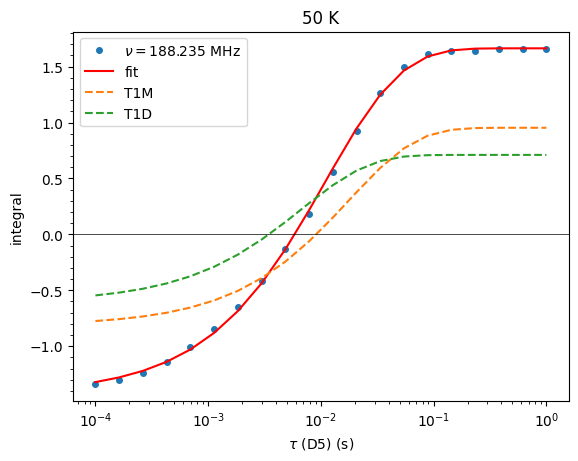

s = 0.8561888692409895 +/- 0.010877231969494963
T1M = 0.017675826287718913 +/- 0.0005897279811614964
r = 0.7255456894039964 +/- 0.02447771248098033
y0 = 0.2841015016732115 +/- 0.001886880699079289

----------------------------------------------------------------------------------------------------

Temperature: 55 K, interpolated spectral parameters:
    -Intrinsic component: 188.247 MHz, sigma = 0.037 MHz
    -Defect component: 188.177 MHz, sigma = 0.071 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.344
Fraction of intrinsic component at 188.234 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.564


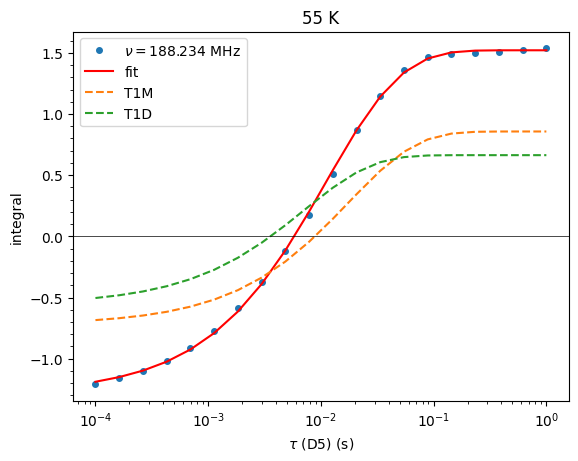

s = 0.8429813125109559 +/- 0.008769255783999065
T1M = 0.017578135529925737 +/- 0.0004851333933104438
r = 0.7182228078871229 +/- 0.020000239524824666
y0 = 0.24831079413333595 +/- 0.0013247694323362052

----------------------------------------------------------------------------------------------------

Temperature: 60 K, interpolated spectral parameters:
    -Intrinsic component: 188.246 MHz, sigma = 0.036 MHz
    -Defect component: 188.180 MHz, sigma = 0.066 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.340
Fraction of intrinsic component at 188.232 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.545


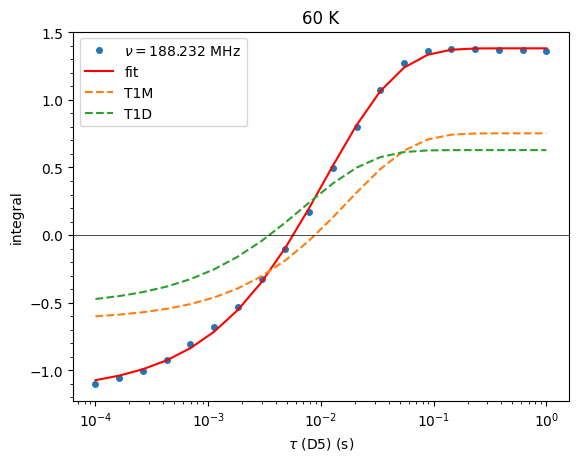

s = 0.8361843405248386 +/- 0.012068514897728195
T1M = 0.017222366865728176 +/- 0.0006726161265841038
r = 0.7500238053279418 +/- 0.030375944849507213
y0 = 0.2143123632313687 +/- 0.0015883869935945409

----------------------------------------------------------------------------------------------------

Temperature: 70 K, interpolated spectral parameters:
    -Intrinsic component: 188.244 MHz, sigma = 0.034 MHz
    -Defect component: 188.182 MHz, sigma = 0.056 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.375
Fraction of intrinsic component at 188.23 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.568


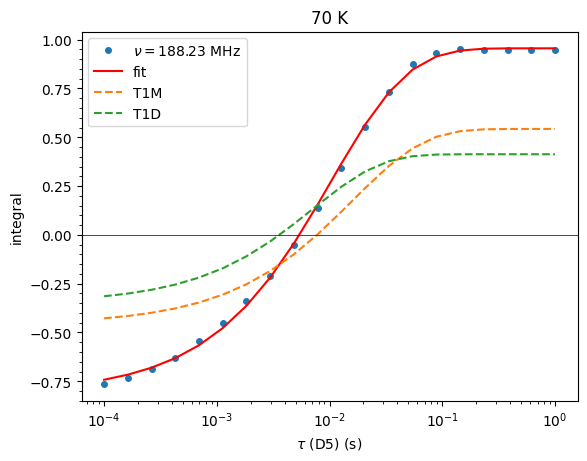

s = 0.8455025591693293 +/- 0.015290344549473195
T1M = 0.01590816974870409 +/- 0.0007419782634675755
r = 0.68047269394729 +/- 0.03169461248763105
y0 = 0.1340928544666657 +/- 0.0011656814201018088

----------------------------------------------------------------------------------------------------

Temperature: 75 K, interpolated spectral parameters:
    -Intrinsic component: 188.244 MHz, sigma = 0.033 MHz
    -Defect component: 188.183 MHz, sigma = 0.054 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.408
Fraction of intrinsic component at 188.233 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.620


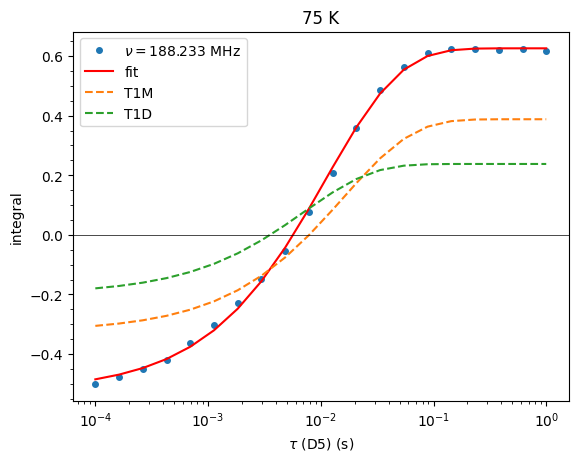

s = 0.8371351907704776 +/- 0.014982698668241203
T1M = 0.015946269611765117 +/- 0.0006684997030198412
r = 0.7062791445574961 +/- 0.030280013893708695
y0 = 0.08344239400719879 +/- 0.0007232714028021343

----------------------------------------------------------------------------------------------------

Temperature: 80 K, interpolated spectral parameters:
    -Intrinsic component: 188.241 MHz, sigma = 0.033 MHz
    -Defect component: 188.183 MHz, sigma = 0.049 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.495
Fraction of intrinsic component at 188.234 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.712


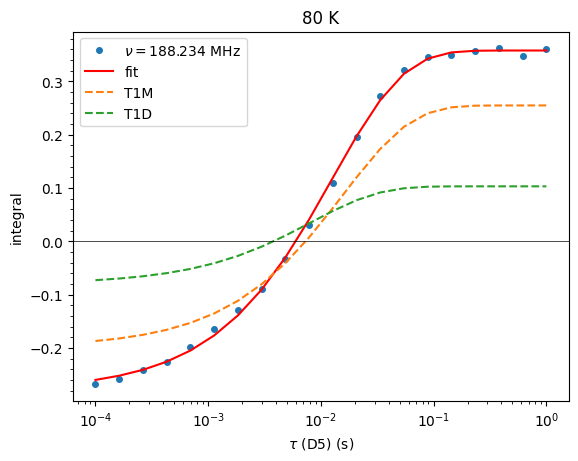

s = 0.781191413151751 +/- 0.015722637040282962
T1M = 0.01580336603388883 +/- 0.00062626512370162
r = 0.7165848606177366 +/- 0.02961009806838124
y0 = 0.04313790777012585 +/- 0.0003959267023166279

----------------------------------------------------------------------------------------------------

Temperature: 85 K, interpolated spectral parameters:
    -Intrinsic component: 188.241 MHz, sigma = 0.033 MHz
    -Defect component: 188.183 MHz, sigma = 0.044 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.614
Fraction of intrinsic component at 188.233 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.799


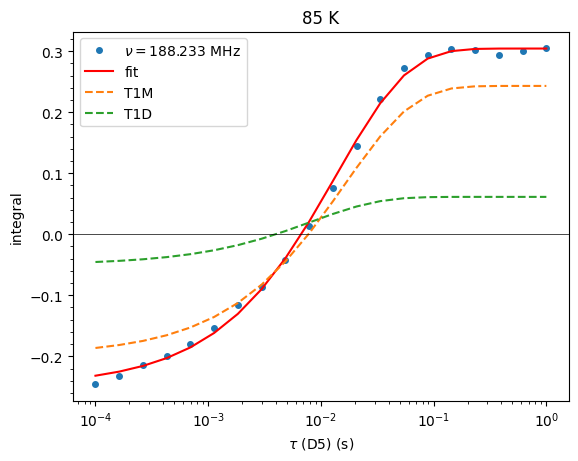

s = 0.8166678365674689 +/- 0.02275899763087041
T1M = 0.016140011487265356 +/- 0.0008102961029656702
r = 0.7037608578872421 +/- 0.03638771546017357
y0 = 0.03326037556622119 +/- 0.00043924383489875204

----------------------------------------------------------------------------------------------------

Temperature: 90 K, interpolated spectral parameters:
    -Intrinsic component: 188.237 MHz, sigma = 0.034 MHz
    -Defect component: 188.182 MHz, sigma = 0.043 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.667
Fraction of intrinsic component at 188.234 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.840


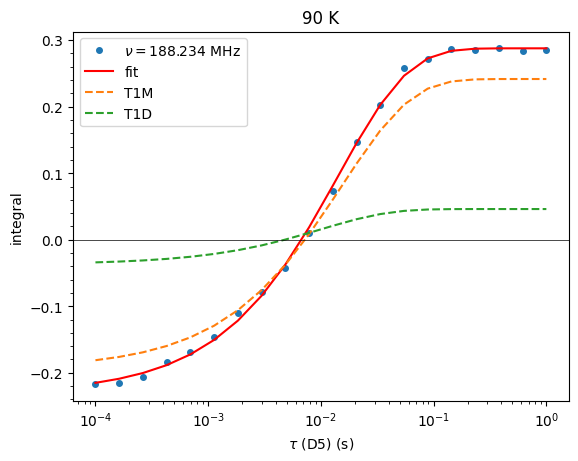

s = 0.8017531032850997 +/- 0.017211557890099878
T1M = 0.015404729669648252 +/- 0.0005561483026269116
r = 0.7005557479734192 +/- 0.026185169122179715
y0 = 0.03087391053427901 +/- 0.000301216244820518

----------------------------------------------------------------------------------------------------

Temperature: 95 K, interpolated spectral parameters:
    -Intrinsic component: 188.236 MHz, sigma = 0.033 MHz
    -Defect component: 188.182 MHz, sigma = 0.042 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.679
Fraction of intrinsic component at 188.232 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.843


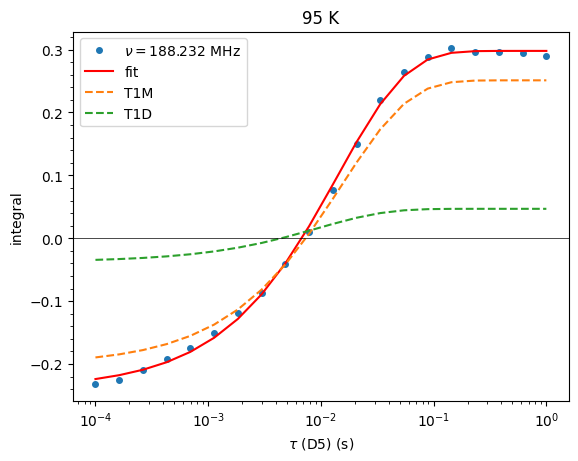

s = 0.8021863451356845 +/- 0.01738919516872082
T1M = 0.015331346101767288 +/- 0.0005548262680135219
r = 0.7203042101586695 +/- 0.02749557454071092
y0 = 0.031310626809662186 +/- 0.0003125869988586517

----------------------------------------------------------------------------------------------------

Temperature: 100 K, interpolated spectral parameters:
    -Intrinsic component: 188.236 MHz, sigma = 0.033 MHz
    -Defect component: 188.182 MHz, sigma = 0.040 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.692
Fraction of intrinsic component at 188.231 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.850


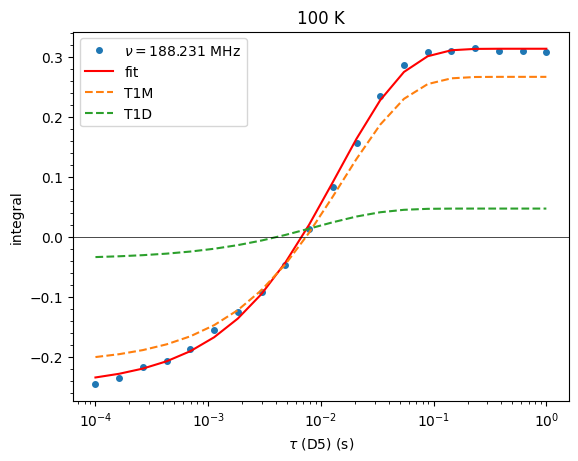

s = 0.7957794336537294 +/- 0.018465494476174734
T1M = 0.015284883737196213 +/- 0.0005829523955248452
r = 0.7417177280378615 +/- 0.03043193263780653
y0 = 0.032307508910926416 +/- 0.0003477459544431909

----------------------------------------------------------------------------------------------------

Temperature: 110 K, interpolated spectral parameters:
    -Intrinsic component: 188.234 MHz, sigma = 0.031 MHz
    -Defect component: 188.182 MHz, sigma = 0.034 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.649
Fraction of intrinsic component at 188.225 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.814


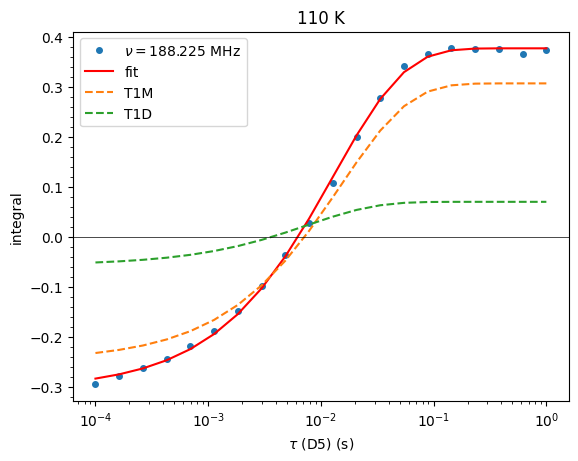

s = 0.8075365236552372 +/- 0.015145183688059961
T1M = 0.015008548367154519 +/- 0.00048593289490538646
r = 0.709103769296541 +/- 0.023958225941212698
y0 = 0.037954203149980895 +/- 0.00032428018891208664

----------------------------------------------------------------------------------------------------

Temperature: 115 K, interpolated spectral parameters:
    -Intrinsic component: 188.233 MHz, sigma = 0.031 MHz
    -Defect component: 188.182 MHz, sigma = 0.034 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.633
Fraction of intrinsic component at 188.223 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.790


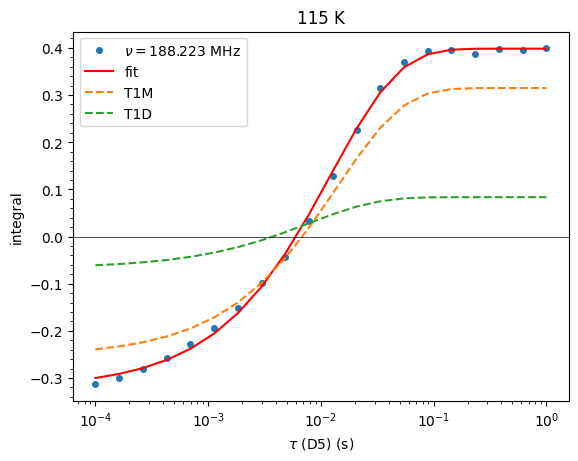

s = 0.8058713345110109 +/- 0.01919525799770122
T1M = 0.013980535132663723 +/- 0.0005792355621196836
r = 0.7383797124471293 +/- 0.03307082893375899
y0 = 0.04022688155397019 +/- 0.0004311482541089092

----------------------------------------------------------------------------------------------------

Temperature: 120 K, interpolated spectral parameters:
    -Intrinsic component: 188.232 MHz, sigma = 0.031 MHz
    -Defect component: 188.182 MHz, sigma = 0.033 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.617
Fraction of intrinsic component at 188.222 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.773


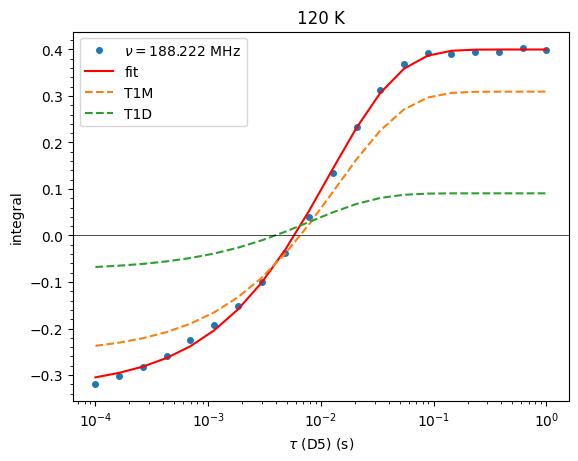

s = 0.8229144403706203 +/- 0.018308223503352716
T1M = 0.013495339204016066 +/- 0.0005355562445691701
r = 0.7087668406615418 +/- 0.029724329317007154
y0 = 0.04047446038525473 +/- 0.0003968696788940866

----------------------------------------------------------------------------------------------------

Temperature: 130 K, interpolated spectral parameters:
    -Intrinsic component: 188.231 MHz, sigma = 0.030 MHz
    -Defect component: 188.182 MHz, sigma = 0.031 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.591
Fraction of intrinsic component at 188.217 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.721


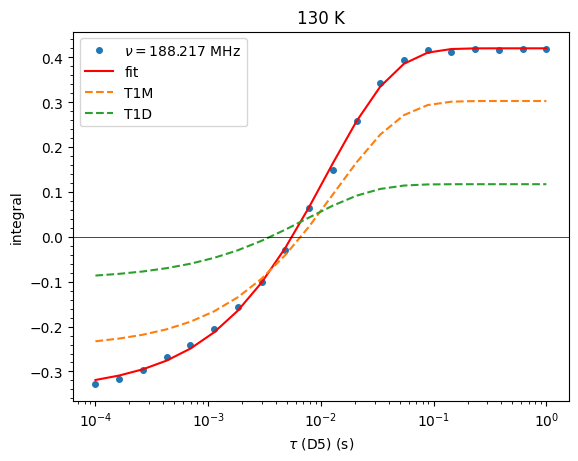

s = 0.8152972147136455 +/- 0.013419868384158677
T1M = 0.013295445849305702 +/- 0.00041378898947461086
r = 0.7449062957176017 +/- 0.02530074001714584
y0 = 0.04208815478863097 +/- 0.0003096224144042125

----------------------------------------------------------------------------------------------------

Temperature: 140 K, interpolated spectral parameters:
    -Intrinsic component: 188.229 MHz, sigma = 0.029 MHz
    -Defect component: 188.182 MHz, sigma = 0.029 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.566
Fraction of intrinsic component at 188.212 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.655


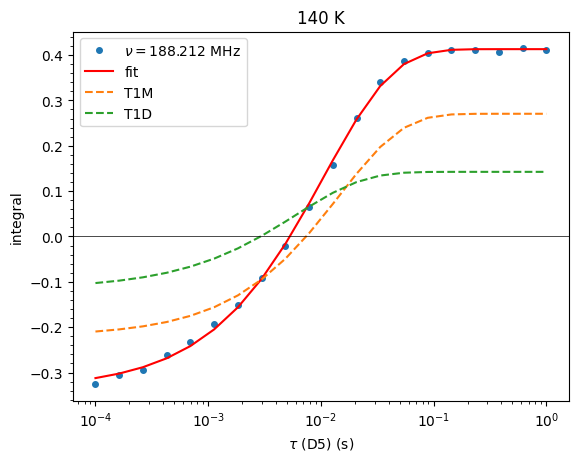

s = 0.8135051447847709 +/- 0.013452369546423273
T1M = 0.014564386286632775 +/- 0.000511106065027101
r = 0.7694697848881191 +/- 0.029401250558263738
y0 = 0.04079173061505574 +/- 0.00031884732083513334

----------------------------------------------------------------------------------------------------

Temperature: 150 K, interpolated spectral parameters:
    -Intrinsic component: 188.228 MHz, sigma = 0.028 MHz
    -Defect component: 188.182 MHz, sigma = 0.028 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.564
Fraction of intrinsic component at 188.21 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.635


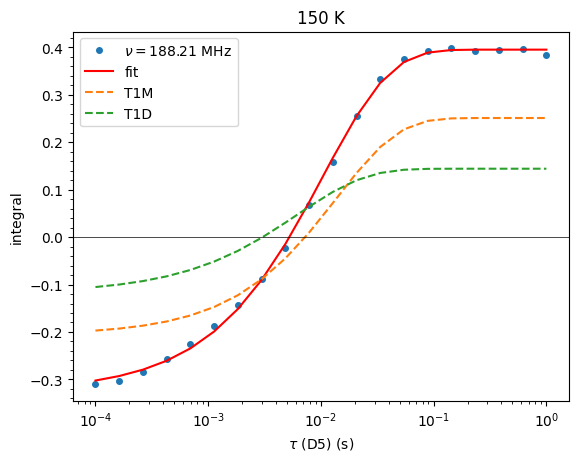

s = 0.8217321132927919 +/- 0.014618281691288293
T1M = 0.01386389868299957 +/- 0.0005337280130787369
r = 0.7905470937955725 +/- 0.03397861219246191
y0 = 0.038271865206589865 +/- 0.0003220960291273755

----------------------------------------------------------------------------------------------------

Temperature: 160 K, interpolated spectral parameters:
    -Intrinsic component: 188.227 MHz, sigma = 0.027 MHz
    -Defect component: 188.182 MHz, sigma = 0.027 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.562
Fraction of intrinsic component at 188.209 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.628


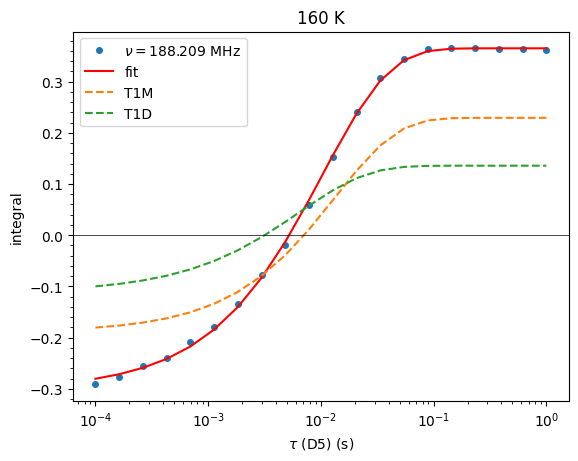

s = 0.8249896207447185 +/- 0.01140704857199227
T1M = 0.01351432623562656 +/- 0.0004070958535511786
r = 0.787533837164242 +/- 0.02655683650316269
y0 = 0.03461529291065037 +/- 0.00022433974583566742

----------------------------------------------------------------------------------------------------

Temperature: 170 K, interpolated spectral parameters:
    -Intrinsic component: 188.226 MHz, sigma = 0.026 MHz
    -Defect component: 188.182 MHz, sigma = 0.026 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.561
Fraction of intrinsic component at 188.207 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.611


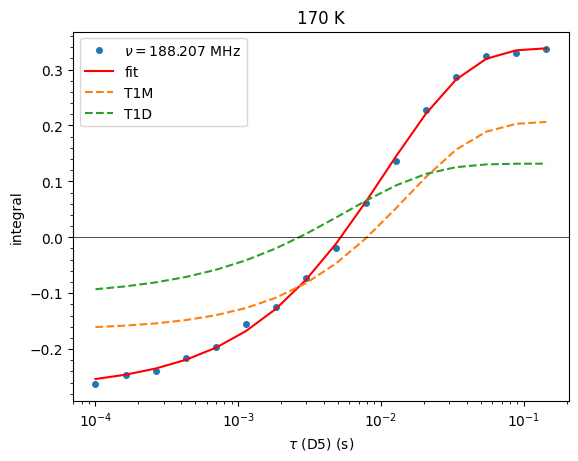

s = 0.8024063220668005 +/- 0.014820001138154572
T1M = 0.014816215264719802 +/- 0.0007047870682859681
r = 0.8537947156046454 +/- 0.03930103192266785
y0 = 0.031185192908858964 +/- 0.0004503102419061738

----------------------------------------------------------------------------------------------------

Temperature: 180 K, interpolated spectral parameters:
    -Intrinsic component: 188.224 MHz, sigma = 0.026 MHz
    -Defect component: 188.182 MHz, sigma = 0.025 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.559
Fraction of intrinsic component at 188.206 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.608


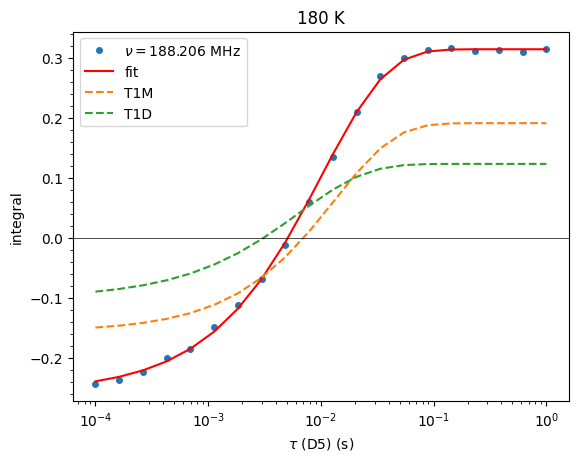

s = 0.8176111013197827 +/- 0.01069382416377107
T1M = 0.01330976516574121 +/- 0.0003880838822101759
r = 0.8059989820919602 +/- 0.026710697812881715
y0 = 0.02811464560778547 +/- 0.00017192863042102835

----------------------------------------------------------------------------------------------------

Temperature: 200 K, interpolated spectral parameters:
    -Intrinsic component: 188.222 MHz, sigma = 0.025 MHz
    -Defect component: 188.181 MHz, sigma = 0.024 MHz
    -Relative intensity of intrinsic component: r = k**3 = 0.576
Fraction of intrinsic component at 188.205 MHz: r*G_int/(r*G_int+(1-r)*G_def) = 0.625


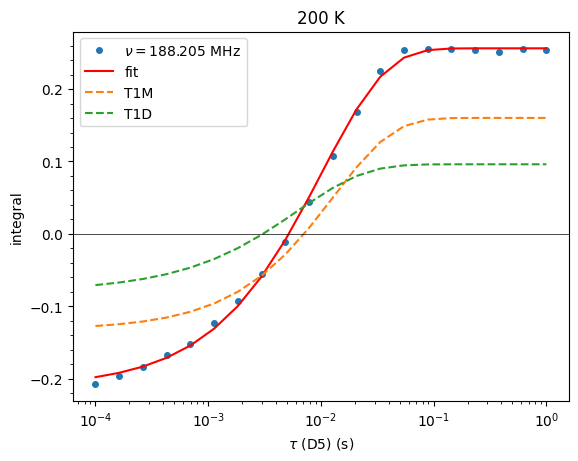

s = 0.8268751204077693 +/- 0.016949938882407083
T1M = 0.013110069361888604 +/- 0.0005822396866920649
r = 0.8244652720428671 +/- 0.042319150592214805
y0 = 0.022115146290939552 +/- 0.00021510022992575785

----------------------------------------------------------------------------------------------------



In [18]:
chi_sum=0 
chiis=[]
zap=0
#A dictionary where the results will be written
magParamsResults={'T':[], 'y0':[], 'y0_err':[], 'T1M':[], 'T1M_err':[], 'r':[], 'r_err':[], 's':[], 's_err':[], '$\chi^2$':[]}

while zap < len(X0):
#while zap < 1:
    Y=X0[zap]
    temp=X0[dictX0['{:}'.format(Y)]]
    
    i=0
    while i< len(dataMag):
        if dataMag.iloc[i,0]==float(Y):
            break
        elif i<41:
            i+=1
        else:
            print('Temperature not matched')
    
    X=dataMag.iloc[i,1]      #The frequency where T1 was measured on the peak!
     
    Q1='{0}.{1}'.format(str(Y)[0],str(Y)[2:])
    Q2='{0}'.format(str(Y))
    if Y<4.0:
        fileXnu = r'T1_all/T1_{0}K.txt'.format(Q1)
    else:
        fileXnu = r'T1_all/T1_{0}K.txt'.format(Q2)
    columns1 = ['t', 'integral']
    intXnu=pd.read_csv(fileXnu, sep="	", names=columns1)
    
    xdata=intXnu.iloc[:,0]
    ydata=intXnu.iloc[:,1]
    
    #Interpolation
    spekter = get_params(Y)
    a = 1
    nu = spekter['freq1']
    nu1 = spekter['freq2']
    b = spekter['sigma1']
    b1 = spekter['sigma2']
    k = spekter['k']**3
    nu3=X

    print(r'Temperature: {0} K, interpolated spectral parameters:'.format(temp))
    print(r'    -Intrinsic component: {0:.3f} MHz, sigma = {1:.3f} MHz'.format(nu, b))
    print(r'    -Defect component: {0:.3f} MHz, sigma = {1:.3f} MHz'.format(nu1, b1))
    print(r'    -Relative intensity of intrinsic component: r = k**3 = {0:.3f}'.format(k))
    print(r'Fraction of intrinsic component at {0} MHz: r*G_int/(r*G_int+(1-r)*G_def) = {1:.3f}'.format(X, intrinsic_fraction(k, X, nu, b, nu1, b1)))
    
    T1D=T1d_values.iloc[zap,1]
       
    #fit
    model=Model(fitmagnetizacija)
    params=model.make_params()
 
    if zap==0:
        params['s'].value = 0.9
        params['T1M'].value = 0.05
        params['r'].value = 0.7
        params['y0'].value = 20
    else:
        params['s'].value=result.params['s'].value
        params['T1M'].value=result.params['T1M'].value
        params['r'].value=result.params['r'].value
        params['y0'].value=result.params['y0'].value
         
    params['T1M'].min = 0.005
    params['r'].min = 0.5
    params['r'].max = 1.0
    params['r'].vary=True
    params['T1M'].max = 1.0
    params['s'].min = 0.0 
    params['s'].max = 1.0

    result=model.fit(ydata,params,t=xdata)
 
    s=result.params['s'].value
    T1M=result.params['T1M'].value
    r=result.params['r'].value
    y0=result.params['y0'].value
    chi_ind=result.chisqr
    chi_sum+=chi_ind
    chiis=np.append(chiis,chi_ind)
     
    #plot
    fig = plt.figure()
    ax = fig.gca()
    plt.title(r'{0} K'.format(Y))
    ax.plot(xdata,ydata, "o",markersize=4,label=r'$\nu=${0} MHz'.format(X))
    ax.plot(xdata,result.best_fit,'r-',label='fit')
    ax.plot(xdata,main(xdata,s,T1M,r,y0), "--",markersize=2,label=r'T1M')
    ax.plot(xdata,defect(xdata,s,y0), "--",markersize=2,label=r'T1D')
    plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    plt.xscale('log')
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    plt.xlabel(r"$\tau$ (D5) (s)")
    plt.ylabel(r'integral')
    plt.legend(loc='best', prop={'size': 10})
    plt.show()
     
    #data extraction

    #print('chi^2=',chi_ind)
    for key in result.params:
        print(key, "=", result.params[key].value, "+/-", result.params[key].stderr)
        magParamsResults['{:}'.format(key)].append(result.params['{:}'.format(key)].value)
        magParamsResults['{:}_err'.format(key)].append(result.params['{:}'.format(key)].stderr)
    magParamsResults['T'].append(Y)
    magParamsResults['$\chi^2$'].append(chi_ind)
    zap+=1
    print('\n----------------------------------------------------------------------------------------------------\n')

## Saving and plotting the results

In [19]:
datafile=pd.DataFrame(magParamsResults, index=None) 
#print(datafile)
datafile.to_csv(r'T1_intrinsic_analysis_Oct26.txt', sep='\t', index=None)   

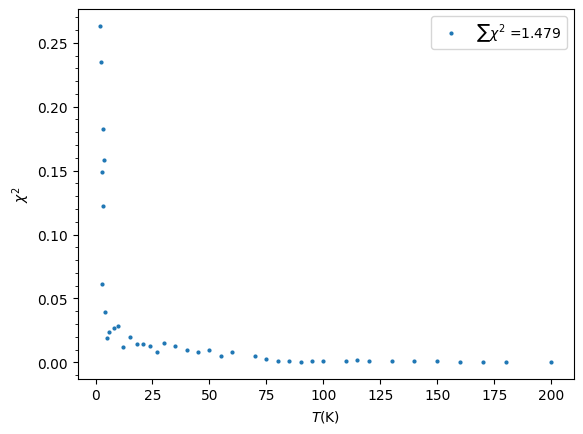

In [20]:
fig = plt.figure()
ax = fig.gca()
ax.plot(X0,chiis, "o", markersize=2, label=r'$\sum \chi^2$ ={:.3f}'.format(chi_sum))
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xlabel(r"$T$(K)")
plt.ylabel(r'$\chi^2$')
plt.legend(loc='best', prop={'size': 10})
plt.show()

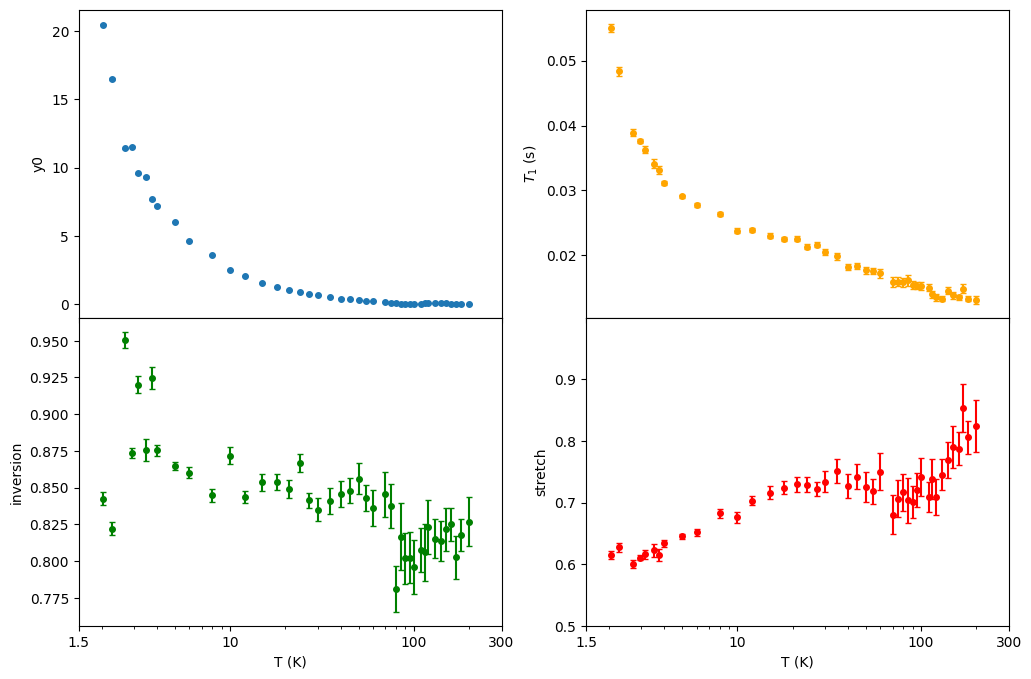

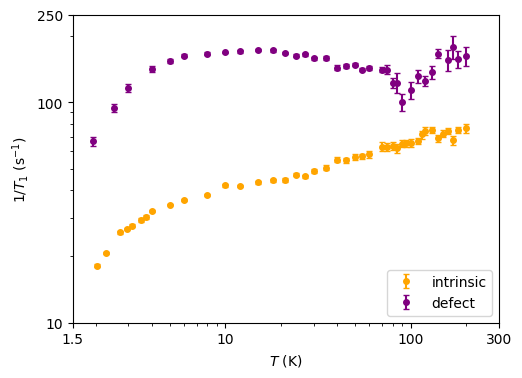

In [25]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, sharex=True, figsize=(12, 8), gridspec_kw={'hspace': 0})

T = magParamsResults['T']

ax1.errorbar(T, magParamsResults['y0'],  yerr=magParamsResults['y0_err'], fmt='o', markersize=4, capsize=2)
ax2.errorbar(T, magParamsResults['T1M'], yerr=magParamsResults['T1M_err'], fmt='o', color='orange', markersize=4, capsize=2)
ax3.errorbar(T, magParamsResults['s'],   yerr=magParamsResults['s_err'], fmt='o', color='green', markersize=4, capsize=2)
ax4.errorbar(T, magParamsResults['r'],   yerr=magParamsResults['r_err'], fmt='o', color='red', markersize=4, capsize=2)

ax1.set_xscale('log')
ax1.set(ylabel='y0')
ax2.set(ylabel='$T_{1}$ (s)')
ax3.set(xlabel='T (K)', ylabel='inversion')
ax4.set(xlabel='T (K)', ylabel='stretch')
ax4.set_ylim(0.5, 1)
ax4.yaxis.get_major_locator().set_params(prune='upper')
ax3.set_xticks([1.5, 10, 100, 300])
ax3.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v:g}'))
ax4.set_xticks([1.5, 10, 100, 300])
ax4.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v:g}'))

# 1/T1 plot
T1M = np.array(magParamsResults['T1M'])
T1M_err = np.array(magParamsResults['T1M_err'])
T1D = np.array(T1d_original['T1'])
T1D_err = np.array(T1d_original['err T1'])

fig2, ax = plt.subplots(figsize=(5.5, 4))
ax.errorbar(T, 1/T1M, yerr=T1M_err/T1M**2, fmt='o', color='orange', markersize=4, capsize=2, label='intrinsic')
ax.errorbar(T1d_original['T'], 1/T1D, yerr=T1D_err/T1D**2, fmt='o', color='purple', markersize=4, capsize=2, label='defect')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1.5, 300)
ax.set_ylim(10, 250)
ax.set_xticks([1.5, 10, 100, 300])
ax.set_yticks([10, 100, 250])
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v:g}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v:g}'))
ax.set_xlabel(r"$T$ (K)")
ax.set_ylabel(r'$1/T_{1}$ (s$^{-1}$)')
plt.legend(loc=4);

## What was the fraction of the intrinsic line at the frequencies where the defect T1 was measured?

We originally determined the frequencies for the defect line T1 measurements according to the simple two-gaussian fits so that there was only 2% of the intrinsic line at the measurement frequency. This fraction will now be different since our fits are different. So how much?

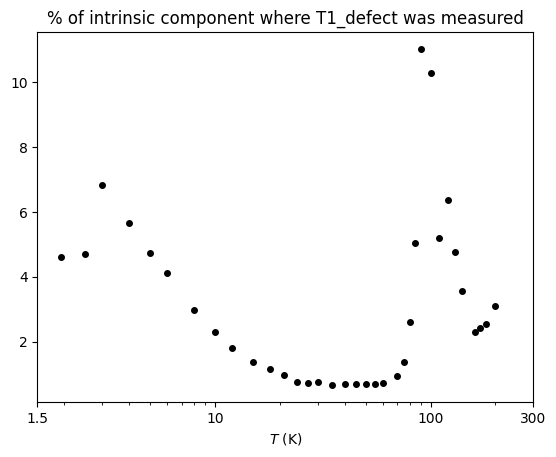

In [55]:
percentOfIntrinsic = []

for index in range(len(T1d_original)):
    temperature = T1d_original['T'][index]
    X = T1d_original['FR'][index] 
    spekter = get_params(temperature)
    a = 1
    nu = spekter['freq1']
    nu1 = spekter['freq2']
    b = spekter['sigma1']
    b1 = spekter['sigma2']
    k = spekter['k']**3

    value = 100*(k)*gaussian(X,1,nu,b) / ((k)*gaussian(X,1,nu,b) + (1-k)*gaussian(X,1,nu1,b1))
    percentOfIntrinsic.append(value)
    
    #print(r'At {2} K, defect T1 was measured at {0} MHz; fraction of the intrinsic component is r*G_int/(r*G_int+(1-r)*G_def) = {1:.3f} %'.format(X, value, temperature))

fig3, ax = plt.subplots();
ax.plot(T1d_original['T'], percentOfIntrinsic, 'o', color='black', markersize=4)
ax.set_xscale('log')
ax.set_xlim(1.5, 300)
ax.set_xticks([1.5, 10, 100, 300])
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v:g}'))
ax.set_xlabel(r"$T$ (K)")
ax.set_title(r'% of intrinsic component where T1_defect was measured');